# Understanding ARTM multi-h CPM

Follow **bits → dibits → overlapping frequency pulses → phase → I/Q → spectrum**.
Here “CPM-H” means ARTM multi-h CPM, the Tier II waveform. A dedicated **Source guide** cell at the end contains the references and reading notes.

The parameter reference is [RCC 106-20, §2.3.3.3](https://www.trmc.osd.mil/wiki/download/attachments/240256843/chapter2.pdf?api=v2&modificationDate=1692197849361&version=1):

| Quantity | Value |
|---|---|
| Bits per symbol | 2; symbol rate $R_s=R_b/2$ |
| Dibit → symbol $a_k$ | 00 → −3, 01 → −1, 10 → +1, 11 → +3 |
| Index $h_k$ | 4/16, 5/16, repeating |
| Frequency pulse | Raised cosine, duration $3T$, $T=1/R_s$ |

Change the parameters below, then run all cells. Defaults use a 1 Mbit/s input; the normalized spectrum also applies at other rates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path

plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'font.size': 11})
OUT = Path('figures')
OUT.mkdir(exist_ok=True)
Rb = 1e6
sps = 32
n_symbols = 32768
seed = 106
h_pair = (4/16, 5/16)
Rs = Rb / 2
T = 1 / Rs
Fs = sps * Rs
assert Rb > 0 and sps >= 16 and n_symbols >= 1024
rng = np.random.default_rng(seed)
bits = rng.integers(0, 2, 2*n_symbols)
dibits = bits.reshape(-1, 2)
a = 4*dibits[:, 0] + 2*dibits[:, 1] - 3
print(f'Rb = {Rb/1e6:g} Mbit/s; Rs = {Rs/1e6:g} Msymbol/s; Fs = {Fs/1e6:g} Msamples/s')
print('First dibits:', [''.join(map(str, b)) for b in dibits[:12]])
print('Symbols:    ', a[:12])

Rb = 1 Mbit/s; Rs = 0.5 Msymbol/s; Fs = 16 Msamples/s
First dibits: ['11', '00', '00', '10', '01', '00', '00', '00', '10', '10', '11', '00']
Symbols:     [ 3 -3 -3  1 -1 -3 -3 -3  1  1  3 -3]


## The pulse and the phase convention

Using symbol-normalized time $u=t/T$, define $G(u)=Tg(Tu)$:

$$G(u)=\frac{1-\cos(2\pi u/L)}{2L},\quad 0\leq u\leq L,\quad L=3.$$

Its integral is $Q(u)=u/(2L)-\sin(2\pi u/L)/(4\pi)$ inside the pulse, zero before it, and $1/2$ afterwards.
Following [Geoghegan's phase equation, PDF page 2](https://www.quasonix.com/files/artm-tier-ii-waveform-itc-paper.pdf):

$$\phi(t)=2\pi\sum_k h_k a_k Q(t/T-k),\qquad z(t)=e^{j\phi(t)}.$$

Differentiating gives the physical frequency deviation in Hz:
$$\Delta f(t)=\frac{1}{T}\sum_k h_k a_k G(t/T-k).$$

Each completed symbol contributes $\pi h_k a_k$ radians. Weight **each symbol** by its index before pulse overlap.
The frequency pulse is a CPM shaping pulse; it is not a root-raised-cosine filter on I/Q.

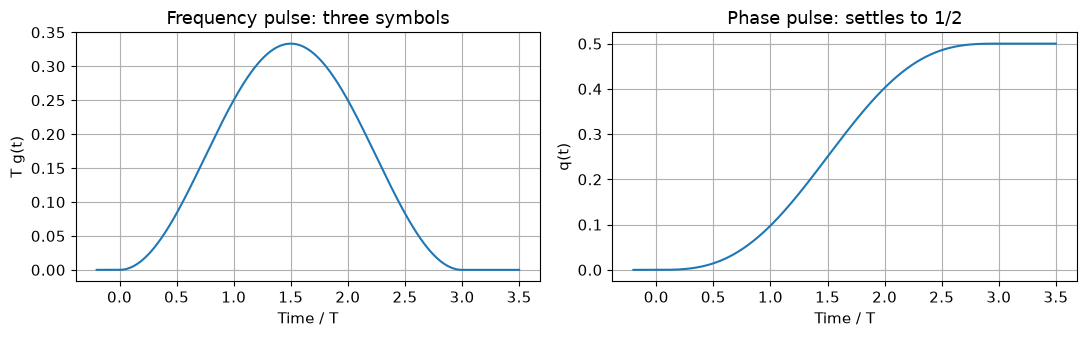

In [2]:
def phase_pulse(u, L=3):
    v = np.clip(np.asarray(u, dtype=float), 0, L)
    return v/(2*L) - np.sin(2*np.pi*v/L)/(4*np.pi)

def frequency_pulse(u, L=3):
    u = np.asarray(u, dtype=float)
    return np.where((u >= 0) & (u <= L), (1-np.cos(2*np.pi*u/L))/(2*L), 0)

def modulate(symbols, sps=32, indices=(4/16, 5/16), L=3):
    h = np.resize(np.asarray(indices, dtype=float), len(symbols))
    impulses = np.zeros(len(symbols)*sps)
    impulses[::sps] = symbols*h
    u = np.arange(L*sps+1)/sps
    # Exact phase increments from analytic Q, avoiding integration bias.
    dq = np.diff(phase_pulse(u, L))
    increments = 2*np.pi*np.convolve(impulses, dq)
    phase = np.r_[0., np.cumsum(increments)]
    f_normalized = np.convolve(impulses, frequency_pulse(u, L))
    return np.exp(1j*phase), phase, f_normalized, h

u = np.linspace(-0.2, 3.5, 1000)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(u, frequency_pulse(u)); ax[0].set(xlabel='Time / T', ylabel='T g(t)', title='Frequency pulse: three symbols')
ax[1].plot(u, phase_pulse(u)); ax[1].set(xlabel='Time / T', ylabel='q(t)', title='Phase pulse: settles to 1/2')
fig.tight_layout(); fig.savefig(OUT/'01_pulses.png', dpi=150); plt.show()

## Watch symbols become a waveform

The short record starts with zero prior pulse history. Each pulse lasts three symbols, so neighboring symbols jointly determine frequency. Phase accumulates continuously. I and Q vary, while their combined magnitude remains one. The example carrier below is an illustrative low-frequency carrier, not an actual telemetry RF channel.

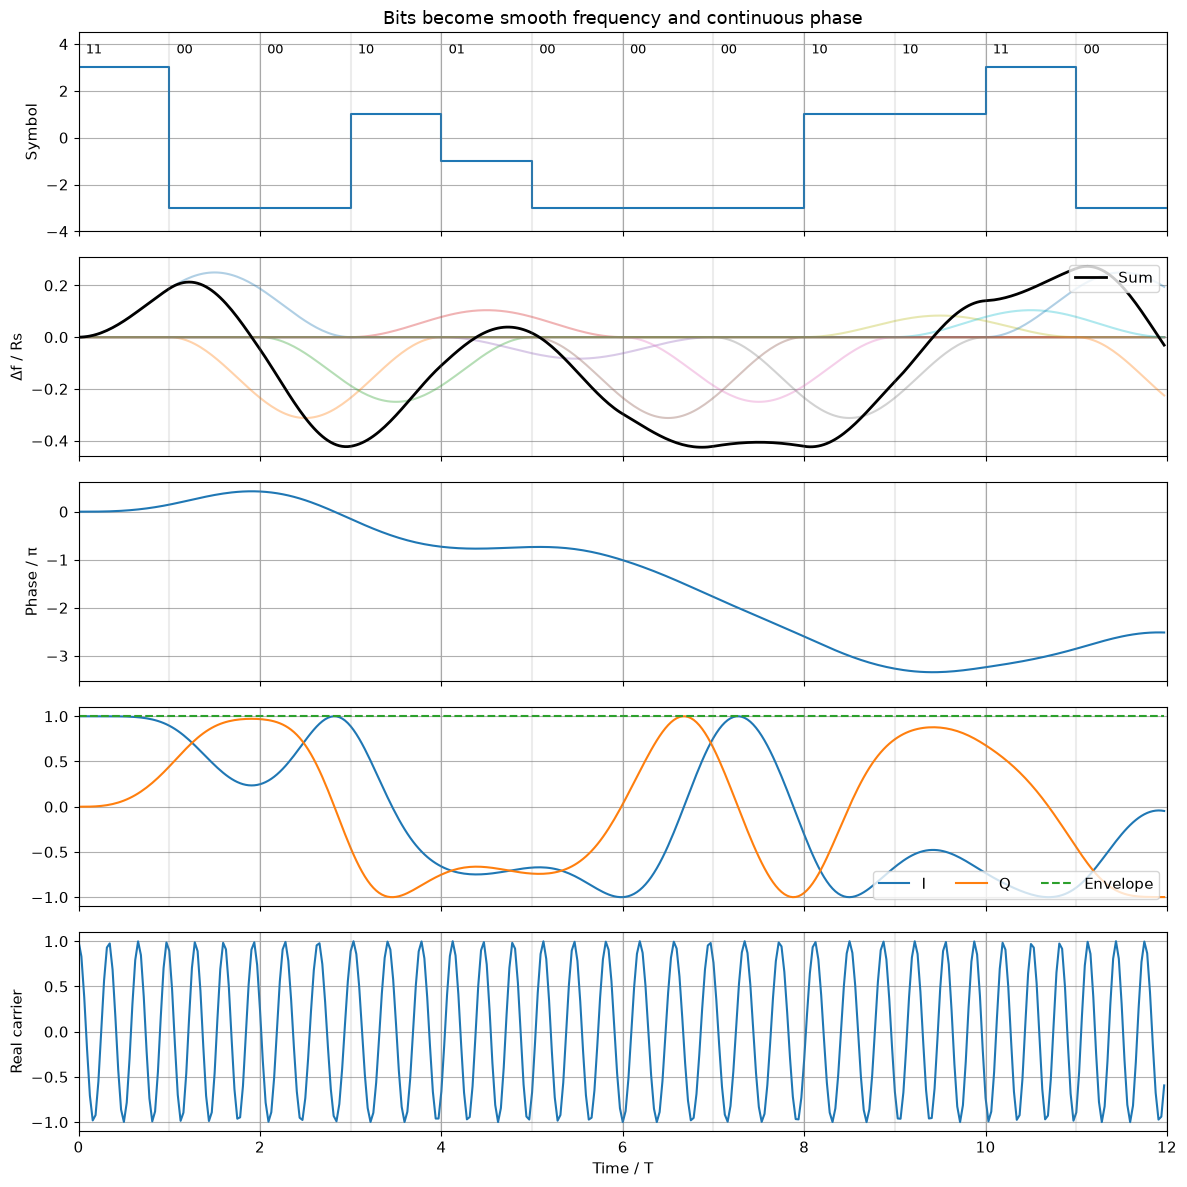

In [3]:
z, phase, fn, h = modulate(a, sps, h_pair)
count = 12*sps
t = np.arange(count)/Fs
x = t/T
fig, ax = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
ax[0].step(np.arange(13), np.r_[a[:12], a[11]], where='post', label='Symbol a[k]')
ax[0].set(ylabel='Symbol', title='Bits become smooth frequency and continuous phase')
for k in range(12):
    ax[0].text(k+.08, 3.6, f'{dibits[k,0]}{dibits[k,1]}', fontsize=9)
ax[0].set_ylim(-4, 4.5)
for k in range(12):
    ax[1].plot(x, h[k]*a[k]*frequency_pulse(x-k), alpha=.35)
ax[1].plot(x, fn[:count], color='black', lw=2, label='Sum')
ax[1].set(ylabel='Δf / Rs'); ax[1].legend(loc='upper right')
ax[2].plot(x, phase[:count]/np.pi); ax[2].set(ylabel='Phase / π')
ax[3].plot(x, z[:count].real, label='I'); ax[3].plot(x, z[:count].imag, label='Q')
ax[3].plot(x, np.abs(z[:count]), '--', label='Envelope'); ax[3].legend(loc='lower right', ncol=3)
carrier = np.real(z[:count]*np.exp(2j*np.pi*(3*Rs)*t))
ax[4].plot(x, carrier); ax[4].set(xlabel='Time / T', ylabel='Real carrier')
for axis in ax:
    for k in range(13): axis.axvline(k, color='grey', alpha=.15)
    axis.set_xlim(0, 12)
fig.tight_layout(); fig.savefig(OUT/'02_signal_chain.png', dpi=150); plt.show()

## Hardware view: the black curve drives an FM modulator

**Yes: the black curve is the frequency command that an ideal FM modulator would follow.**
It is plotted as $\Delta f/R_s$, so multiply its value by $R_s$ to obtain the requested frequency deviation in Hz.
For an analog VCO, convert that frequency command into a voltage using the VCO's tuning sensitivity.

```text
dibits → symbols a[k] → weight by h[k] → overlapping g(t) pulses
       → frequency command Δf(t) → voltage scaling / DAC → VCO → RF waveform
```

### What the pulse represents

$g(t)$ is a prescribed **time-domain frequency-shaping pulse**, not the carrier amplitude and not a spectrum.
For one symbol, $\Delta f_k(t)=h_k a_k g(t-kT)$; the black curve is the sum of all these contributions.
The sign makes a contribution push the frequency up or down, and its magnitude determines how strongly.
Because each pulse lasts $3T$, the current frequency depends on overlapping symbols.
Two successive `00` dibits are valid: both map to −3, but their separate pulses receive alternating indices.

The dimensionless pulse $G(u)=Tg(Tu)$ lets us use the same drawing at any symbol rate.
At a higher rate, the pulses become shorter in seconds and taller in Hz, preserving their frequency-time area.
For a completed symbol, $\int\Delta f_k(t)\,dt=h_k a_k/2$ cycles, or $\pi h_k a_k$ radians.

### From frequency command to control voltage

Assume a locally linear VCO with center-frequency bias $V_0$ and sensitivity $K_v$ in **Hz/V**:

$$f_{\mathrm{inst}}(t)=f_c+K_v[v_{\mathrm{ctrl}}(t)-V_0],\qquad
v_{\mathrm{ctrl}}(t)=V_0+\frac{\Delta f(t)}{K_v}.$$

For example, with $K_v=1$ MHz/V, a command of −200 kHz means a control voltage **0.2 V below the bias**.
Negative deviation means below the carrier frequency; it does not mean a negative RF frequency.

The oscillator accumulates phase naturally:

$$s(t)=A\cos\left(2\pi f_c t+2\pi\int_0^t\Delta f(\tau)\,d\tau+\theta_0\right).$$

Its amplitude $A$ remains constant in this ideal model. Positive deviation speeds up the oscillations;
negative deviation slows them down. Zero deviation returns to the center frequency, **not to zero accumulated phase**.
We never reset phase at a symbol boundary. That is how the FM/VCO route produces continuous phase.
If a VCO specification instead gives sensitivity in rad/s/V, use $\Delta\omega=2\pi\Delta f$ when calculating voltage.

The plot below translates the same black curve into physical frequency and illustrative control-voltage units.
The sensitivity and bias are teaching values, not specifications for a particular component.
Real hardware must reproduce this command with sufficient modulation bandwidth and calibrated tuning;
DAC/reconstruction filtering and VCO nonlinearity can alter it. An equivalent digital implementation accumulates
phase and generates I/Q for upconversion, so a directly modulated analog VCO is one implementation option.

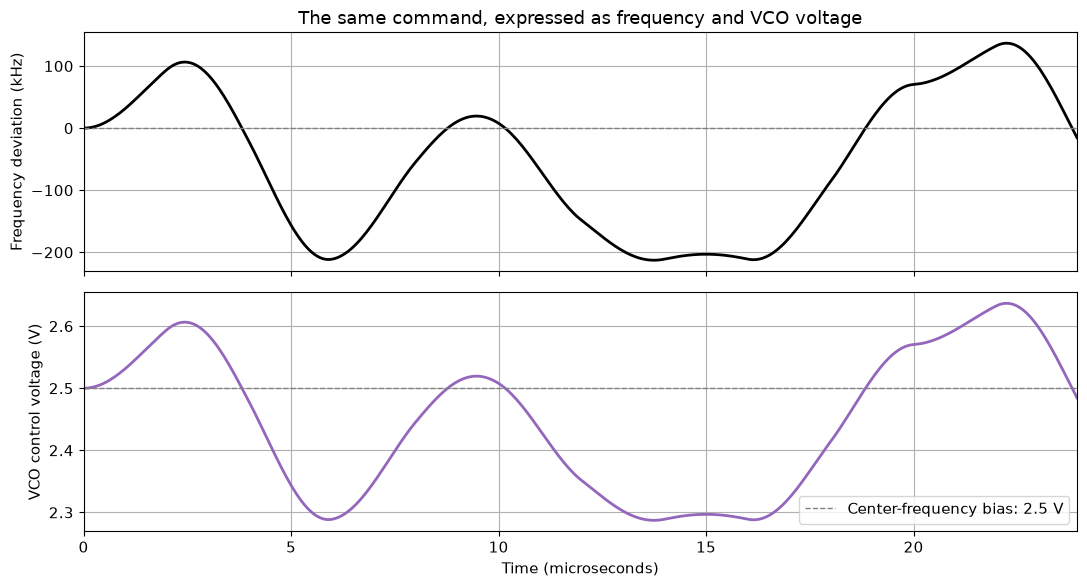

Illustrative sensitivity: 1 MHz/V
Control voltage over this excerpt: 2.287 to 2.637 V


In [4]:
# Illustrative ideal-VCO parameters: change these to explore voltage scaling.
Kv_hz_per_volt = 1e6
v_bias = 2.5
assert Kv_hz_per_volt > 0
deviation_hz = fn[:count] * Rs
control_volts = v_bias + deviation_hz / Kv_hz_per_volt
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t*1e6, deviation_hz/1e3, color='black', lw=2)
ax[0].axhline(0, color='grey', ls='--', lw=1)
ax[0].set(ylabel='Frequency deviation (kHz)', title='The same command, expressed as frequency and VCO voltage')
ax[1].plot(t*1e6, control_volts, color='tab:purple', lw=2)
ax[1].axhline(v_bias, color='grey', ls='--', lw=1, label=f'Center-frequency bias: {v_bias:g} V')
ax[1].set(xlabel='Time (microseconds)', ylabel='VCO control voltage (V)')
ax[1].legend(loc='lower right')
for axis in ax:
    axis.set_xlim(t[0]*1e6, t[-1]*1e6)
fig.tight_layout(); fig.savefig(OUT/'06_vco_control.png', dpi=150); plt.show()
print(f'Illustrative sensitivity: {Kv_hz_per_volt/1e6:g} MHz/V')
print(f'Control voltage over this excerpt: {control_volts.min():.3f} to {control_volts.max():.3f} V')

## Estimate the spectrum

Use a long random record, remove the startup and terminal regions, and average overlapping Hann-windowed FFTs (Welch).
The two-sided complex-baseband spectrum uses frequency offset from the carrier. Its RF counterpart is centered on the chosen carrier frequency.

The vertical axis is $10\log_{10}(R_b S(f)/P)$, a density per normalized frequency $f/R_b$. It is **not** dBm or a peak-normalized spectrum.
The 99% occupied bandwidth below uses the 0.5% and 99.5% cumulative-power quantiles, without assuming exact symmetry.
Finite-record estimates depend on seed, record length, window, and FFT size. This plot does not demonstrate receiver BER or transmitter compliance.

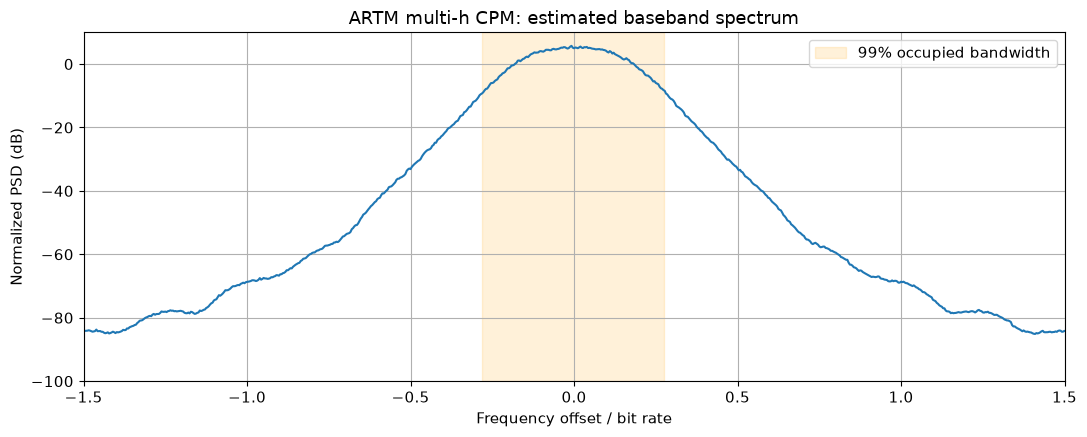

Integrated PSD = 1.000000 (unit signal power expected)
99% bandwidth = 557.2 kHz = 0.5572 × bit rate
FFT bin spacing = 3.906 kHz


In [5]:
def estimate_psd(waveform, samples_per_symbol=sps):
    steady = waveform[8*samples_per_symbol:-8*samples_per_symbol]
    f, p = welch(steady, fs=samples_per_symbol*Rs, window='hann',
                 nperseg=4096, noverlap=2048, detrend=False,
                 return_onesided=False, scaling='density')
    order = np.argsort(f)
    f, p = f[order], p[order]
    df = f[1]-f[0]
    power = p.sum()*df
    cdf = np.cumsum(p)/p.sum()
    lo, hi = np.interp([.005, .995], cdf, f)
    return f, p, power, lo, hi

f, p, power, lo, hi = estimate_psd(z)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(f/Rb, 10*np.log10(np.maximum(p*Rb/power, 1e-15)))
ax.axvspan(lo/Rb, hi/Rb, alpha=.15, color='orange', label='99% occupied bandwidth')
ax.set(xlim=(-1.5, 1.5), ylim=(-100, 10), xlabel='Frequency offset / bit rate',
       ylabel='Normalized PSD (dB)', title='ARTM multi-h CPM: estimated baseband spectrum')
ax.legend(); fig.tight_layout(); fig.savefig(OUT/'03_spectrum.png', dpi=150); plt.show()
print(f'Integrated PSD = {power:.6f} (unit signal power expected)')
print(f'99% bandwidth = {(hi-lo)/1e3:.1f} kHz = {(hi-lo)/Rb:.4f} × bit rate')
print(f'FFT bin spacing = {(f[1]-f[0])/1e3:.3f} kHz')

## What changes when the pulse or index changes?

Hold the dibits and bit rate fixed. Compare the standard waveform with a one-symbol raised-cosine pulse and a fixed average index. These alternatives are teaching experiments. Spectra alone cannot explain the detection advantage of multiple indices; that requires a receiver or distance analysis. See [Rice and Perrins](https://scholarsarchive.byu.edu/facpub/392/) for receiver background.

ARTM: 3RC, alternating h: B99/Rb = 0.5572


Experiment: 1RC, alternating h: B99/Rb = 1.3340
Experiment: 3RC, fixed average h: B99/Rb = 0.5528


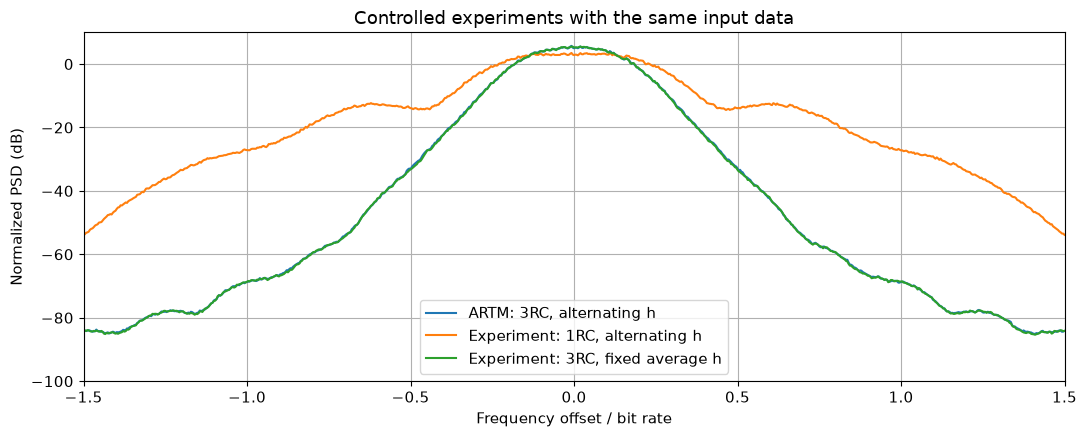

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for label, indices, length in [
    ('ARTM: 3RC, alternating h', h_pair, 3),
    ('Experiment: 1RC, alternating h', h_pair, 1),
    ('Experiment: 3RC, fixed average h', (np.mean(h_pair),), 3),
]:
    zz, *_ = modulate(a, sps, indices, length)
    ff, pp, pw, low, high = estimate_psd(zz)
    ax.plot(ff/Rb, 10*np.log10(np.maximum(pp*Rb/pw, 1e-15)), label=label)
    print(f'{label}: B99/Rb = {(high-low)/Rb:.4f}')
ax.set(xlim=(-1.5, 1.5), ylim=(-100, 10), xlabel='Frequency offset / bit rate',
       ylabel='Normalized PSD (dB)', title='Controlled experiments with the same input data')
ax.legend(); fig.tight_layout(); fig.savefig(OUT/'04_comparison.png', dpi=150); plt.show()

## Checking against the paper's Figure 3

The supplied screenshot uses **Power (dBc)**, while our earlier plot is a density per normalized frequency.
For an analyzer's effective noise bandwidth $B$, narrow-band power is approximately
$10\log_{10}[S(f)B/P]$, differing from our plot by $10\log_{10}(B/R_b)$.
Figure 3 and its accompanying text do not specify the bandwidth or full estimator settings, so we cannot recover an absolute dBc calibration from that figure alone.

Below we compare **shape** by making each curve's peak 0 dB. No horizontal scaling or waveform parameters are fitted.
Orange points are approximate manual readings of the black curve in the user-supplied screenshot of
[Geoghegan Figure 3](https://www.quasonix.com/files/artm-tier-ii-waveform-itc-paper.pdf).
They are not the author's numerical data. Pixel coordinates are retained so the readings are reviewable.
The image spans x=173 to 532 for frequency −2 to +2 and y=42 to 313 for −10 to −90 dBc.
The black peak is approximately y=47.5. Line thickness, overlap, and reading the peak introduce uncertainty.

As an independent computational check, average the autocorrelation over equiprobable symbols and the two-symbol index cycle:

$$R(\tau)=\frac12\int_0^2\prod_k \frac{\cos(3v_k)+\cos(v_k)}2\,du,$$
$$v_k=2\pi h_k[Q(u+\tau-k)-Q(u-k)].$$

Here $u,\tau$ are in symbols. The product follows from independence of the four equally likely symbol values.
Fourier-transforming this autocorrelation predicts the time-averaged PSD without generating a random waveform or using Welch.
This is a derivation from the model, not a separate external standards certification.

Ensemble PSD refinement change within |f/Rb| <= 1: 0.0000 dB


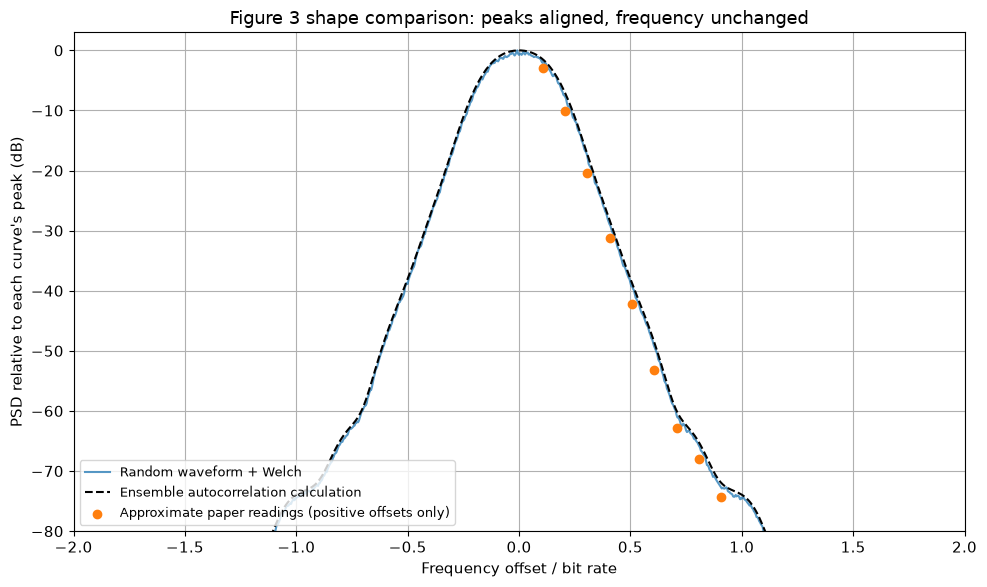

Offset/Rb  Paper approx.  Ensemble   Paper minus ensemble (dB)
   0.106         -2.95      -1.47        -1.48
   0.206        -10.04      -7.03        -3.01
   0.306        -20.37     -17.28        -3.09
   0.407        -31.14     -28.25        -2.89
   0.507        -42.21     -38.69        -3.52
   0.607        -53.14     -48.57        -4.56
   0.708        -62.88     -59.97        -2.91
   0.808        -68.04     -65.23        -2.82
   0.908        -74.24     -71.97        -2.27


In [7]:
def ensemble_psd(samples_per_symbol=32, integration_points=128, max_lag_symbols=32):
    # Midpoint quadrature across both alternating-index intervals.
    u = (np.arange(integration_points)+.5)*2/integration_points
    count = max_lag_symbols*samples_per_symbol
    corr = np.empty(count+1)
    for j in range(count+1):
        lag = j/samples_per_symbol
        k = np.arange(-3, int(np.ceil(lag))+3)
        hk = np.asarray(h_pair)[k % 2]
        dq = phase_pulse(u[:, None]+lag-k) - phase_pulse(u[:, None]-k)
        v = 2*np.pi*hk*dq
        corr[j] = np.prod((np.cos(3*v)+np.cos(v))/2, axis=1).mean()
    even_corr = np.r_[corr, corr[-2:0:-1]]
    spectrum = np.fft.fftshift(np.fft.fft(even_corr).real)/samples_per_symbol
    frequency = np.fft.fftshift(np.fft.fftfreq(len(even_corr), 1/samples_per_symbol))/2
    # Factor 2 converts density per f/Rs into density per f/Rb.
    return frequency, 2*spectrum, corr

ft, pt, correlation = ensemble_psd()
ft_refined, pt_refined, _ = ensemble_psd(64, 256)
assert np.allclose(ft, ft_refined[len(ft)//2:3*len(ft)//2])
pt_refined_common = pt_refined[len(ft)//2:3*len(ft)//2]
visible = (np.abs(ft) <= 1) & (pt > pt.max()*1e-9)
refinement_db = np.max(np.abs(10*np.log10(pt[visible]/pt_refined_common[visible])))
assert refinement_db < .1
assert abs(correlation[-1]) < 1e-12
print(f'Ensemble PSD refinement change within |f/Rb| <= 1: {refinement_db:.4f} dB')

# Manual right-hand black-curve readings, avoiding the annotation and grid lines.
paper_pixels = np.array([
    [362,57.5], [371,81.5], [380,116.5], [389,153.0],
    [398,190.5], [407,227.5], [416,260.5], [425,278.0], [434,299.0],
])
paper_f = -2 + 4*(paper_pixels[:,0]-173)/(532-173)
paper_relative_db = -80*(paper_pixels[:,1]-47.5)/(313-42)
theory_db = 10*np.log10(np.maximum(pt/pt.max(), 1e-15))
simulation_db = 10*np.log10(np.maximum(p/p.max(), 1e-15))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(f/Rb, simulation_db, alpha=.75, label='Random waveform + Welch')
ax.plot(ft, theory_db, '--', color='black', label='Ensemble autocorrelation calculation')
ax.scatter(paper_f, paper_relative_db, color='tab:orange', marker='o',
           label='Approximate paper readings (positive offsets only)', zorder=5)
ax.set(xlim=(-2,2), ylim=(-80,3), xlabel='Frequency offset / bit rate',
       ylabel="PSD relative to each curve's peak (dB)",
       title='Figure 3 shape comparison: peaks aligned, frequency unchanged')
ax.legend(loc='lower left', fontsize=9)
fig.tight_layout(); fig.savefig(OUT/'05_paper_comparison.png', dpi=150); plt.show()
print('Offset/Rb  Paper approx.  Ensemble   Paper minus ensemble (dB)')
for ff, yy in zip(paper_f, paper_relative_db):
    prediction = np.interp(ff, ft, theory_db)
    print(f'{ff:8.3f} {yy:13.2f} {prediction:10.2f} {yy-prediction:12.2f}')

**Interpretation:** the simulated spectrum can be checked against the ensemble prediction independently of the paper image.
The paper points provide an approximate external shape comparison, not exact agreement. A remaining few-dB difference must not be
erased by adjusting the modulation indices or rescaling frequency. The screenshot alone cannot establish its cause.
Our earlier 99% bandwidth is computed from integrated simulated power; it cannot be read from the paper's −90 dBc crossing.

## Numerical checks and experiments to try

Check pulse area, completed-symbol phase, unit envelope, analytic phase reconstruction, and PSD power. These checks validate the implementation convention; they are not an independent standards conformance test.

Try doubling the bit rate: bandwidth in Hz doubles while the normalized shape stays similar. Try doubling samples per symbol to examine sampling sensitivity. Change the seed and record length to see spectral-estimation variability. Avoid treating a short repeated bit pattern as random telemetry; it can introduce spectral lines.

In [8]:
assert np.array_equal(4*np.array([0,0,1,1])+2*np.array([0,1,0,1])-3, [-3,-1,1,3])
assert np.isclose(np.sum(frequency_pulse(np.arange(3*sps+1)/sps))/sps, .5)
assert np.max(np.abs(np.abs(z)-1)) < 1e-12
assert np.isclose(phase[-1], np.pi*np.dot(a, h), atol=1e-8)
short = a[:8]
zs, phs, _, hs = modulate(short, sps, h_pair)
us = np.arange(len(phs))/sps
reference = 2*np.pi*sum(hs[k]*short[k]*phase_pulse(us-k) for k in range(len(short)))
assert np.max(np.abs(phs-reference)) < 1e-10
assert abs(power-1) < .02
print('All numerical checks passed.')

All numerical checks passed.


## Source guide

Retrieved 24 September 2026. “CPM-H” is interpreted here as ARTM multi-h CPM (Tier II).

1. [RCC 106-20, Chapter 2 (July 2020)](https://www.trmc.osd.mil/wiki/download/attachments/240256843/chapter2.pdf?api=v2&modificationDate=1692197849361&version=1). Start at section 2.3.3.3, printed pages 2-9 to 2-11, especially equation 2-11 and Table 2-6. Primary parameter reference: four dibit levels, three-symbol raised-cosine frequency pulse, and alternating indices 4/16 and 5/16. This is a dated reference edition, not a claim about the latest standard.
2. [Mark Geoghegan, Description and Performance Results for the Advanced Range Telemetry (ARTM) Tier II Waveform (ITC 2000)](https://www.quasonix.com/files/artm-tier-ii-waveform-itc-paper.pdf). Read PDF page 2 for the phase equations; page 3 for pulse, phase-tree and spectrum illustrations. Explains the reasons for pulse shaping and alternating indices, and the receiver complexity tradeoff. The notebook follows its explicit phase convention, with pulse integral 1/2 and phase multiplier 2π.
3. [Michael Rice and Erik Perrins, The Detection Efficiency of ARTM CPM in Aeronautical Telemetry (2005)](https://scholarsarchive.byu.edu/facpub/392/). Author repository record and abstract; useful for a later receiver notebook. Examines reduced-complexity detection. Only the repository abstract was reviewed for this starter; no BER results are reproduced.
4. [Keysight, Custom IQ — ARTM Multi-h CPM](https://helpfiles.keysight.com/csg/n5186/Content/CMOD/Custom%20IQ%20ARTM%20Multi-h%20CPM.htm). Practical cross-check: order 4, RC3 filter, h1=0.25 and h2=0.3125. Also flags phase closure when looping waveform files.

### Notebook scope

An educational complex-baseband modulator and spectrum experiment. Independent random bits approximate a randomized input. No framing, standard randomizer, channel coding, receiver, RF hardware impairments, or spectral-mask compliance test is implemented. Comparisons to altered pulse lengths or indices are experiments, not other standardized telemetry waveforms.